# MLP Training on `micro_mobility_training_data_2025.csv`

This notebook trains an `MLPRegressor` with the same chronological split logic as your baseline (last 7 days holdout).


## Colab Setup

- This notebook auto-detects Colab and mounts Google Drive.
- Update `COLAB_PROJECT_ROOT` if your Drive path is different.
- Keep your folder structure the same as local project.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [2]:
# Paths and config
# Set this to your repo folder under Google Drive (same structure as local project)
COLAB_PROJECT_ROOT = Path('/content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction')

IN_COLAB = False
try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    PROJECT_ROOT = COLAB_PROJECT_ROOT
else:
    # local fallback
    PROJECT_ROOT = Path.cwd().resolve().parents[1]

DATA_PATH = PROJECT_ROOT / 'data' / 'proceed' / 'micro_mobility_training_data_2025.csv'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'model_training' / 'mlp' / 'v1'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

HOLDOUT_DAYS = 7
RANDOM_STATE = 42

print('IN_COLAB:', IN_COLAB)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_PATH:', DATA_PATH)
print('ARTIFACT_DIR:', ARTIFACT_DIR)


Mounted at /content/drive
IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction
DATA_PATH: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2025.csv
ARTIFACT_DIR: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/v1


In [3]:
# Load data
cols = [
    'station', 'date', 'hour', 'net_demand',
    'lat', 'lng', 'hour_sin', 'hour_cos', 'day_of_week', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]

df = pd.read_csv(DATA_PATH, usecols=cols)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'station', 'net_demand']).copy()

# Stable station encoding for MLP
stations_sorted = sorted(df['station'].dropna().unique().tolist())
station_to_id = {s: i for i, s in enumerate(stations_sorted)}
df['station_id'] = df['station'].map(station_to_id).astype('int32')

# Chronological split
cutoff_date = df['date'].max().normalize() - pd.Timedelta(days=HOLDOUT_DAYS)
train_mask = df['date'] <= cutoff_date
test_mask = df['date'] > cutoff_date

feature_cols = [
    'station_id', 'hour', 'lat', 'lng', 'hour_sin', 'hour_cos',
    'day_of_week', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]

X_train = df.loc[train_mask, feature_cols].astype('float32')
y_train = df.loc[train_mask, 'net_demand'].astype('float32')
X_test = df.loc[test_mask, feature_cols].astype('float32')
y_test = df.loc[test_mask, 'net_demand'].astype('float32')

test_dates = df.loc[test_mask, 'date'].reset_index(drop=True)
test_hours = df.loc[test_mask, 'hour'].astype('int16').reset_index(drop=True)

print('Rows total:', len(df))
print('Train rows:', len(X_train))
print('Test rows:', len(X_test))
print('Cutoff date:', cutoff_date.date())


Rows total: 4266120
Train rows: 4184304
Test rows: 81816
Cutoff date: 2025-12-24


In [5]:
# Model: scale inputs + scale target for stable MLP optimization
import time

base_mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=4096,
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.05,
    n_iter_no_change=5,
    random_state=RANDOM_STATE,
    verbose=True,
)

model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('x_scaler', StandardScaler(with_mean=True, with_std=True)),
        ('mlp', base_mlp),
    ]),
    transformer=StandardScaler(with_mean=True, with_std=True)
)

t0 = time.perf_counter()
model.fit(X_train, y_train)
train_seconds = time.perf_counter() - t0

pred = model.predict(X_test)

rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
mae = float(mean_absolute_error(y_test, pred))
print(f'RMSE: {rmse:.4f}')
print(f'MAE : {mae:.4f}')
print(f'Training time: {train_seconds:.2f} sec ({train_seconds/60:.2f} min)')


Iteration 1, loss = 0.00721442
Validation score: 0.999667
Iteration 2, loss = 0.00011943
Validation score: 0.999833
Iteration 3, loss = 0.00006981
Validation score: 0.999883
Iteration 4, loss = 0.00005754
Validation score: 0.999893
Iteration 5, loss = 0.00005743
Validation score: 0.999950
Iteration 6, loss = 0.00004553
Validation score: 0.999862
Iteration 7, loss = 0.00005107
Validation score: 0.999970
Iteration 8, loss = 0.00003743
Validation score: 0.999978
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.
RMSE: 0.8625
MAE : 0.5463
Training time: 264.74 sec (4.41 min)


In [6]:
# Hourly MAE breakdown (same reporting style as baseline)
eval_df = pd.DataFrame({
    'date': test_dates,
    'hour': test_hours,
    'y_true': y_test.values,
    'y_pred': pred,
})
hourly_mae = eval_df.groupby('hour').apply(
    lambda x: float(np.mean(np.abs(x['y_true'] - x['y_pred'])))
).reset_index(name='mae')

print(hourly_mae)


    hour       mae
0      0  0.529564
1      1  0.449520
2      2  0.440111
3      3  0.419392
4      4  0.481565
5      5  0.508729
6      6  0.561163
7      7  0.587297
8      8  0.630676
9      9  0.675298
10    10  0.588430
11    11  0.560071
12    12  0.534741
13    13  0.506465
14    14  0.504122
15    15  0.510837
16    16  0.542257
17    17  0.569679
18    18  0.604575
19    19  0.590738
20    20  0.614316
21    21  0.565486
22    22  0.545211
23    23  0.590457


/tmp/ipykernel_24535/3778856238.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly_mae = eval_df.groupby('hour').apply(


In [7]:
# Save artifacts
import joblib

model_path = ARTIFACT_DIR / 'mlp_model.joblib'
joblib.dump(model, model_path)

hourly_mae_path = ARTIFACT_DIR / 'hourly_mae.csv'
hourly_mae.to_csv(hourly_mae_path, index=False)

metrics = {
    'data_path': str(DATA_PATH),
    'model': 'MLPRegressor',
    'holdout_days': HOLDOUT_DAYS,
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'cutoff_date': str(cutoff_date),
    'mae': mae,
    'rmse': rmse,
    'feature_columns': feature_cols,
}

metrics_path = ARTIFACT_DIR / 'metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('Saved:')
print('-', model_path)
print('-', hourly_mae_path)
print('-', metrics_path)


Saved:
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/v1/mlp_model.joblib
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/v1/hourly_mae.csv
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/v1/metrics.json


## Plot the diagrams using stored artifacts.

Loading model for visualization...


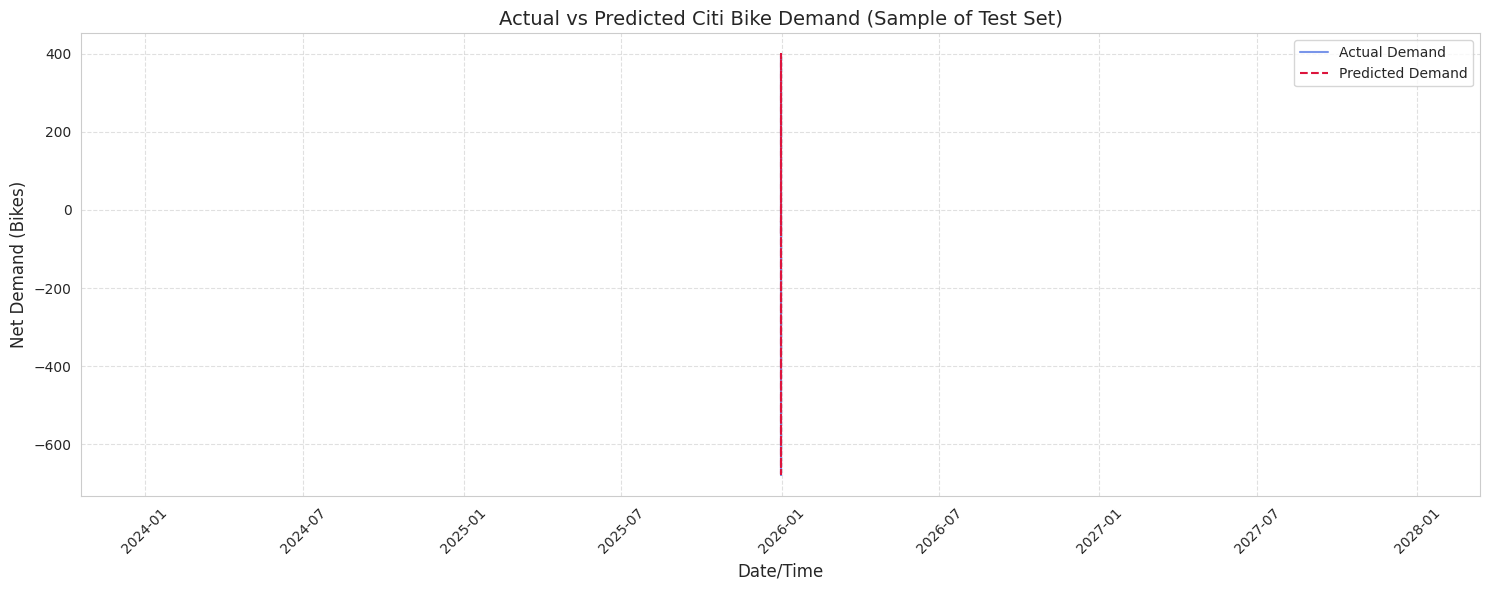

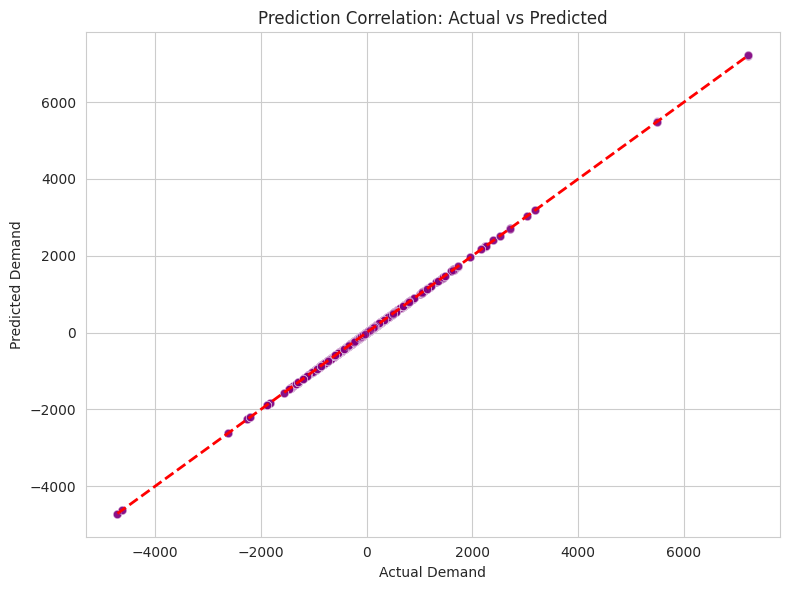

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

# 1. Load the final model from the checkpoint
print("Loading model for visualization...")
loaded_model = joblib.load(model_path)

# 2. Generate predictions
# We use the X_test created in your previous cells
test_pred = loaded_model.predict(X_test)

# 3. Create a DataFrame for plotting
results_df = pd.DataFrame({
    'Date': df.loc[test_mask, 'date'],
    'Actual': y_test.values,
    'Predicted': test_pred
}).sort_values('Date')

# 4. Plotting
plt.figure(figsize=(15, 6))

# Let's plot a subset (e.g., the last 500 observations) for better visibility
# If you want the whole test set, remove the .tail(500)
plot_data = results_df.tail(500)

plt.plot(plot_data['Date'], plot_data['Actual'],
         label="Actual Demand", color="royalblue", alpha=0.7)

plt.plot(plot_data['Date'], plot_data['Predicted'],
         label="Predicted Demand", color="crimson", linestyle='--')

plt.title('Actual vs Predicted Citi Bike Demand (Sample of Test Set)', fontsize=14)
plt.xlabel('Date/Time', fontsize=12)
plt.ylabel('Net Demand (Bikes)', fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Scatter Plot for Correlation
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=test_pred, alpha=0.3, color='purple')

# 45-degree reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.title('Prediction Correlation: Actual vs Predicted')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

plt.tight_layout()
plt.show()

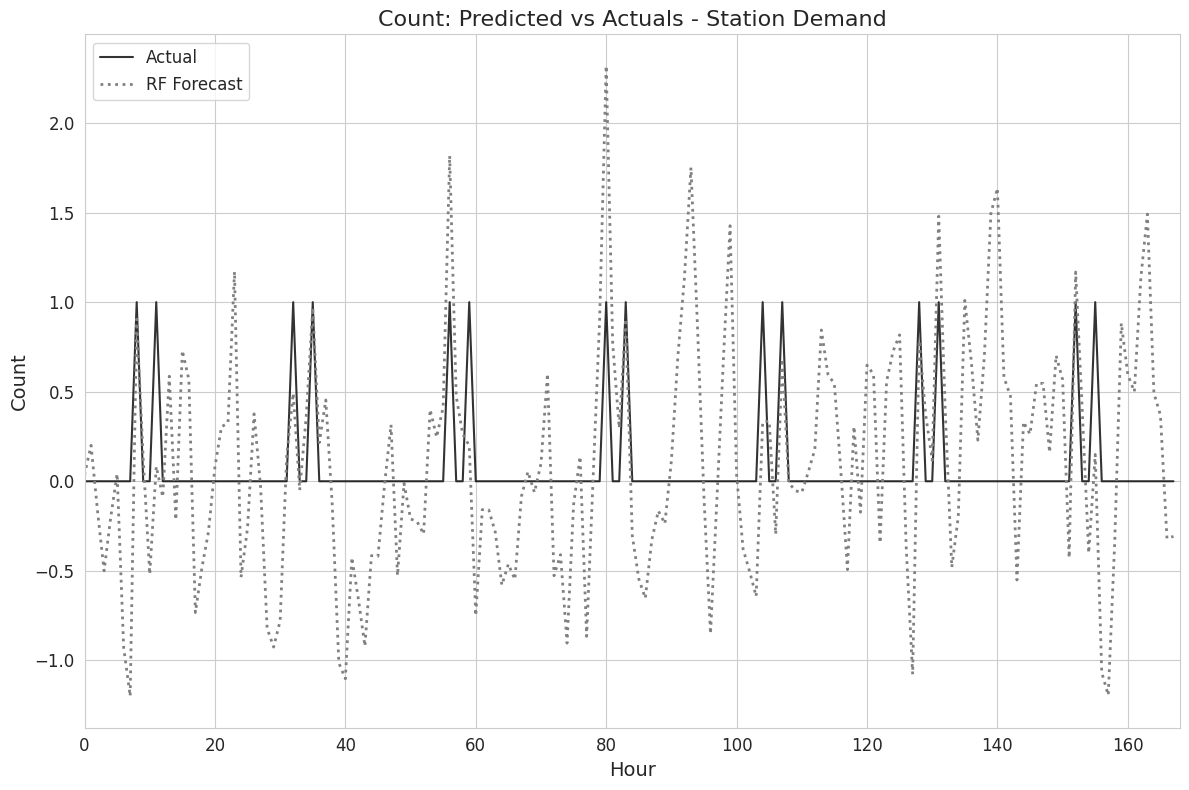

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import joblib

# 1. Load your model and get predictions
# loaded_model = joblib.load(model_path)
train_pred = loaded_model.predict(X_train)

# 2. Prepare the data
# We sample a window of time to match the ~175 hour window in your image
# Assuming your X_test is sorted chronologically
plot_window = 168  # one week of hourly data

y_actual_slice = y_test.values[:plot_window]
y_rf_slice = train_pred[:plot_window]
hours = np.arange(len(y_actual_slice))

# 3. Plotting with the specific styling from your image
plt.figure(figsize=(12, 8))

# Actual Demand - Solid thick line
plt.plot(hours, y_actual_slice,
         label='Actual',
         color='black',
         linewidth=1.5,
         alpha=0.8)

# RF Forecast - Dotted line (matching the image)
plt.plot(hours, y_rf_slice,
         label='RF Forecast',
         color='gray',
         linestyle=':',
         linewidth=2)

# Styling to match the uploaded image
plt.title('Count: Predicted vs Actuals - Station Demand', fontsize=16)
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(loc='upper left', frameon=True, fontsize=12)

# Adjust ticks and grid
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0, plot_window)

plt.tight_layout()
plt.show()

Generating predictions...

PERFORMANCE COMPARISON
Training RMSE: 0.8611
Testing RMSE:  0.8625
------------------------------
Training MAE:  0.5458
Testing MAE:   0.5463


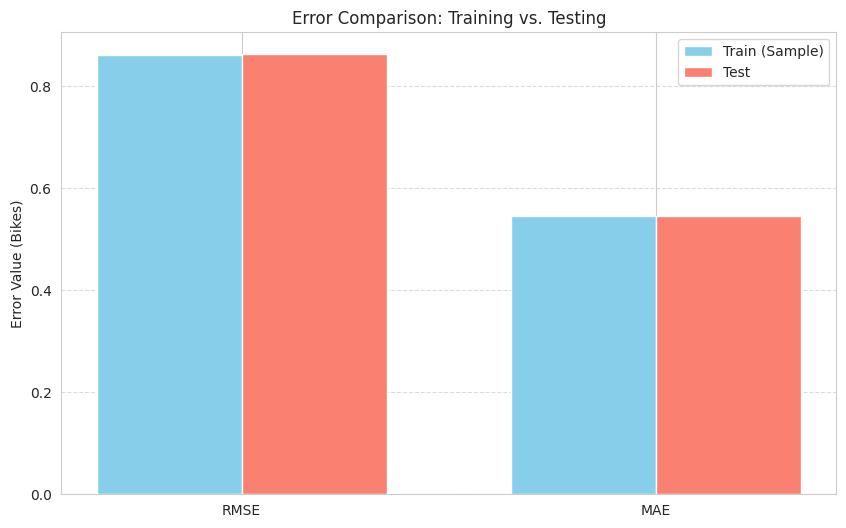

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

# 1. Load the final trained model
# print("Loading model...")
# loaded_model = joblib.load(model_path)

# 2. Sample the training data for faster evaluation
# Calculating errors on 4M+ rows can be slow; 100k-500k is usually enough for a diagnostic
train_sample_size = 500000

X_train_sample = X_train.sample(n=train_sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# 3. Generate Predictions
print("Generating predictions...")
train_preds = loaded_model.predict(X_train_sample)
test_preds = loaded_model.predict(X_test)

# 4. Calculate Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_sample, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_mae = mean_absolute_error(y_train_sample, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)

# 5. Print Comparison
print("\n" + "=" * 30)
print("PERFORMANCE COMPARISON")
print("=" * 30)
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE:  {test_rmse:.4f}")
print("-" * 30)
print(f"Training MAE:  {train_mae:.4f}")
print(f"Testing MAE:   {test_mae:.4f}")
print("=" * 30)

# 6. Visualize the Gap
labels = ['RMSE', 'MAE']
train_metrics = [train_rmse, train_mae]
test_metrics = [test_rmse, test_mae]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_metrics, width, label='Train (Sample)', color='skyblue')
rects2 = ax.bar(x + width/2, test_metrics, width, label='Test', color='salmon')

ax.set_ylabel('Error Value (Bikes)')
ax.set_title('Error Comparison: Training vs. Testing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()